# CHƯƠNG 4: KẾT QUẢ THỰC NGHIỆM

## **Bước 1:** Đọc dữ liệu

Dữ liệu được lưu dưới dạng tệp CSV và được đọc vào môi trường Python bằng thư viện Pandas.

In [49]:
import pandas as pd

df = pd.read_csv('AirPassengers.csv')

df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


## **Bước 2:** Kiểm tra cấu trúc dữ liệu

- Kiểm tra số lượng bản ghi.
- Kiểm tra số lượng thuộc tính.
- Kiểm tra kiểu dữ liệu của từng thuộc tính.
- Phát hiện dữ liệu thiếu (Missing Values).

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Month       144 non-null    str  
 1   Passengers  144 non-null    int64
dtypes: int64(1), str(1)
memory usage: 2.4 KB


*Nhận xét:*
- Tập dữ liệu gồm 144 quan sát.
- Có 2 thuộc tính: Month và Passengers.
- Không có giá trị khuyết vì số lượng Non-Null bằng tổng số bản ghi.
- Thuộc tính Month có kiểu dữ liệu object, cần chuyển sang kiểu thời gian (datetime) để phục vụ phân tích chuỗi thời gian.
- Thuộc tính Passengers có kiểu số nguyên (int64) và được sử dụng làm biến dự báo

## **Bước 3:** Chuyển đổi cột thời gian

Chuyển cột Month từ kiểu chuỗi sang kiểu ngày tháng để thuận tiện cho việc xử lý chuỗi thời gian.

In [51]:
df['Month'] = pd.to_datetime(df['Month'])

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Month       144 non-null    datetime64[us]
 1   Passengers  144 non-null    int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 2.4 KB


## **Bước 4:** Đặt cột thời gian làm chỉ mục

*Mục đích:* Giúp các mô hình dự báo nhận diện được thứ tự thời gian của dữ liệu.

In [52]:
df.set_index('Month', inplace=True)

df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


## **Bước 5:** Kiểm tra dữ liệu trùng lặp

In [53]:
df.index.duplicated().sum()

np.int64(0)

*Nhận xét:*
- Không phát hiện bản ghi trùng lặp trong tập dữ liệu.
- Dữ liệu đảm bảo tính nhất quán cho quá trình xây dựng mô hình dự báo.

## **Bước 6:** Vẽ đồ thị chuỗi thời gian gốc và phân rã các thành phần của chuỗi thời gian

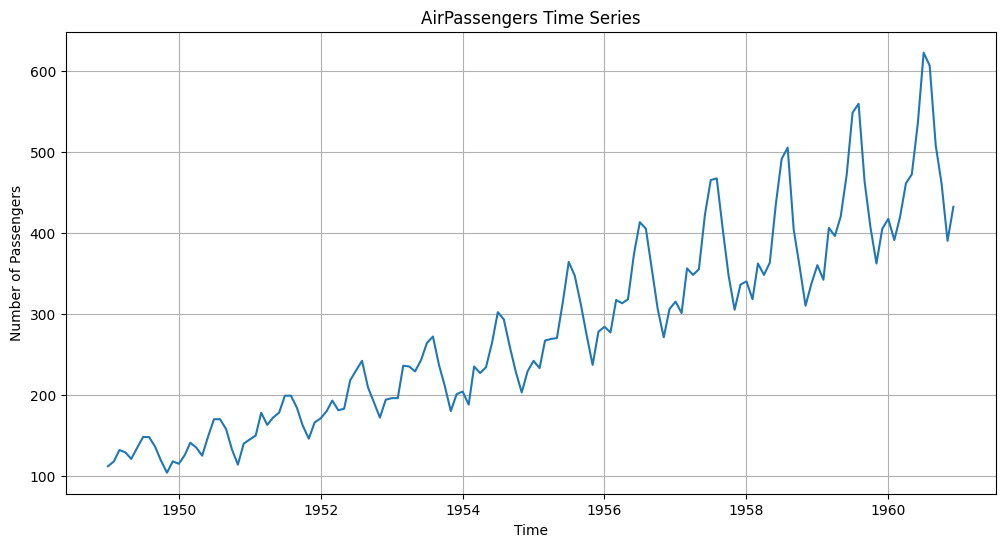

In [54]:
# Vẽ đồ thị chuỗi thời gian gốc
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df.index, df['Passengers'])

plt.title('AirPassengers Time Series')
plt.xlabel('Time')
plt.ylabel('Number of Passengers')

plt.grid(True)
plt.show()

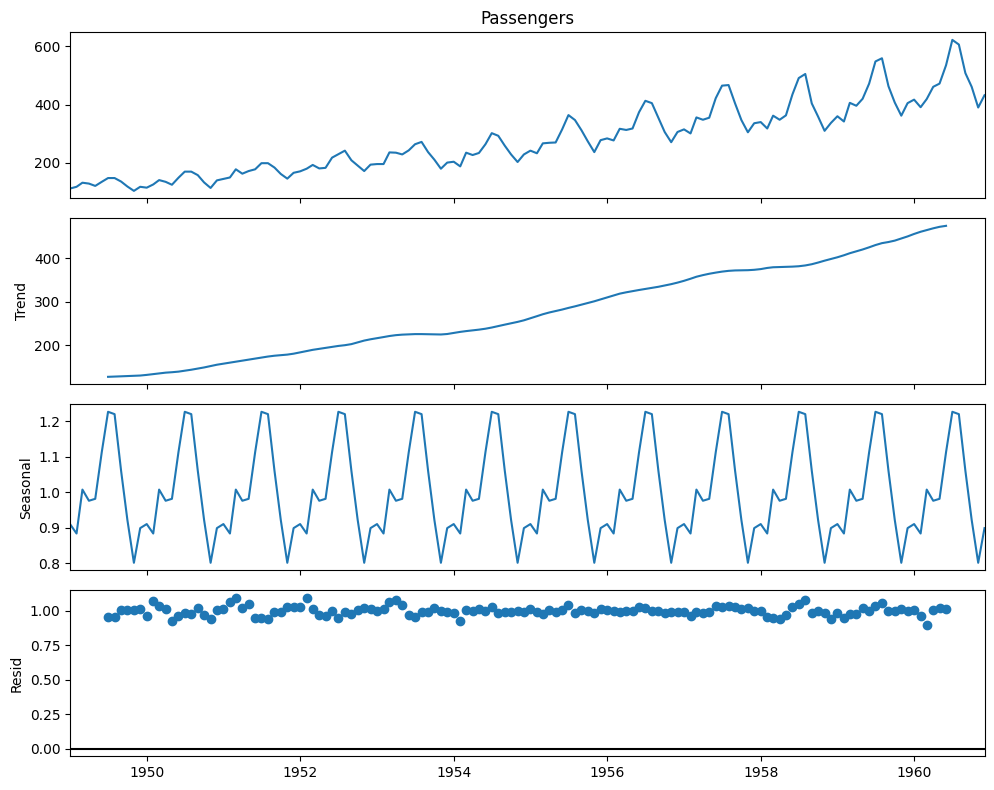

In [55]:
# Phân rã chuỗi thời gian thành các thành phần
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

## Chuỗi thời gian gốc có xu hướng phình to như cái loa theo thời gian
## Nên ta chọn model='multiplicative' (nhân) để phân rã
result = seasonal_decompose(df['Passengers'], model='multiplicative') 

## Vẽ đồ thị tách riêng theo các thành phần
plt.rc("figure", figsize=(10, 8))
result.plot()
plt.show()

In [56]:
# Kiểm định Ljung-Box để kiểm tra xem chuỗi thời gian còn tính tự tương quan không
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = result.resid.dropna()
ljungbox_test = acorr_ljungbox(residuals, lags=[12, 24], return_df=True)
print(ljungbox_test)

       lb_stat     lb_pvalue
12   92.075916  1.954680e-14
24  150.494871  2.680568e-20


*Nhận xét:*

**Quan sát đồ thị cho thấy:**

- Số lượng hành khách có xu hướng tăng dần theo thời gian.
- Xuất hiện tính mùa vụ rõ rệt theo chu kỳ năm.
- Biên độ dao động mùa vụ tăng dần khi mức dữ liệu tăng.
- Thành phần nhiễu dao động ngẫu nhiên và ổn định quanh mức $1.0$
- Kiểm định Ljung-Box đã xác nhận rằng chuỗi phần dư này chưa phải là nhiễu trắng

## **Bước 8:** Thiết lập thực nghiệm
**Chia tập huấn luyện và kiểm tra:** Bộ dữ liệu được chia thành hai phần: tập huấn luyện (90%) dùng để ước lượng các tham số của mô hình và tập kiểm tra (10% - trọn vẹn 1 chu kỳ mùa vụ, tức là 12 tháng) dùng để đánh giá khả năng dự báo.

In [57]:
train = df.iloc[:-12]
test = df.iloc[-12:]

# Đặt tần suất cho tập train và test là 'MS' (Month Start)
train.index.freq = 'MS'
test.index.freq = 'MS'

print("Train:", len(train))
print("Test:", len(test))

Train: 132
Test: 12


## **Bước 9:** Thực nghiệm các mô hình san phẳng mũ

Thực hiện huấn luyện mô hình với tập Train và thực hiện dự báo với tập Test

**HUẤN LUYỆN MÔ HÌNH VỚI TẬP TRAIN**

In [58]:
# Làm mịn mũ đơn (SES)
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
model_ses = SimpleExpSmoothing(train['Passengers']).fit()
ses_forecast = model_ses.forecast(len(test))

# Làm mịn mũ kép (Thuật toán Holt)
from statsmodels.tsa.holtwinters import ExponentialSmoothing
model_holt = ExponentialSmoothing(
                train['Passengers'],
                trend='add').fit()
holt_forecast = model_holt.forecast(steps=len(test))

# Thuật toán Holt suy giảm (Damped Holt)
model_holt_damped = ExponentialSmoothing(
                    train['Passengers'],
                    trend='add',
                    damped_trend=True).fit()
holt_damped_forecast = model_holt_damped.forecast(steps=len(test))


# Thuật toán Holt-Winters
## 1. Holt-Winters với xu hướng và mùa vụ dạng cộng tính (Additive)
model_hw = ExponentialSmoothing(
            train['Passengers'],
            trend='add',
            seasonal='add',
            seasonal_periods=12).fit()
hw_forecast = model_hw.forecast(steps=len(test))

## 2. Holt-Winters với xu hướng và mùa vụ dạng nhân tính (Multiplicative)
model_hw_mul = ExponentialSmoothing(
                train['Passengers'],
                trend='add',
                seasonal='mul',
                seasonal_periods=12).fit()
hw_mul_forecast = model_hw_mul.forecast(steps=len(test))

# Thuật toán Holt-Winters suy giảm (Damped Holt-Winters)
## 1. Damped Holt-Winters với xu hướng và mùa vụ dạng cộng tính (Additive)
model_hw_damped = ExponentialSmoothing(
                    train['Passengers'],
                    trend='add', seasonal='add',
                    seasonal_periods=12,
                    damped_trend=True).fit()
hw_damped_forecast = model_hw_damped.forecast(steps=len(test))

## 2. Damped Holt-Winters với xu hướng và mùa vụ dạng nhân tính (Multiplicative)
model_hw_mul_damped = ExponentialSmoothing(
                        train['Passengers'],
                        trend='add', seasonal='mul',
                        seasonal_periods=12,
                        damped_trend=True).fit()
hw_mul_damped_forecast = model_hw_mul_damped.forecast(steps=len(test))

**Tối ưu tham số:** Các tham số làm mịn (α, β, γ, ϕ) được ước lượng tự động thông qua cơ chế tối ưu hóa của thư viện **statsmodels** nhằm cực tiểu hóa sai số dự báo trên tập huấn luyện.

Dưới đây là bảng tham số mô hình:

In [59]:
import pandas as pd

# 1. Định nghĩa hàm lấy các tham số chính từ mô hình statsmodels
def get_coefficients(model, is_damped=False, has_trend=True, has_seasonal=True):
    alpha = model.params.get('smoothing_level', '-')
    beta = model.params.get('smoothing_trend', '-') if has_trend else '-'
    gamma = model.params.get('smoothing_seasonal', '-') if has_seasonal else '-'
    phi = model.params.get('damping_trend', '-') if is_damped else '-'
    
    # Làm tròn đến 3 chữ số thập phân nếu là số thực
    return [
        round(alpha, 3) if isinstance(alpha, (int, float)) else alpha,
        round(beta, 3) if isinstance(beta, (int, float)) else beta,
        round(gamma, 3) if isinstance(gamma, (int, float)) else gamma,
        round(phi, 3) if isinstance(phi, (int, float)) else phi
    ]

# 2. Trích xuất hệ số từ các biến mô hình bạn đã fit ở bước trước
data_coefs = {
    'Mô hình': [
        'SES', 'Holt', 'Holt Damped', 
        'HW Additive', 'HW Multiplicative', 
        'HW Additive Damped', 'HW Multiplicative Damped'
    ],
    'α': get_coefficients(model_ses, has_trend=False, has_seasonal=False),
    'β': [
        get_coefficients(model_ses, has_trend=False, has_seasonal=False)[1],
        get_coefficients(model_holt, has_trend=True, has_seasonal=False)[1],
        get_coefficients(model_holt_damped, is_damped=True, has_trend=True, has_seasonal=False)[1],
        get_coefficients(model_hw, has_trend=True, has_seasonal=True)[1],
        get_coefficients(model_hw_mul, has_trend=True, has_seasonal=True)[1],
        get_coefficients(model_hw_damped, is_damped=True, has_trend=True, has_seasonal=True)[1],
        get_coefficients(model_hw_mul_damped, is_damped=True, has_trend=True, has_seasonal=True)[1]
    ],
    'γ': [
        '-', '-', '-',
        get_coefficients(model_hw, has_trend=True, has_seasonal=True)[2],
        get_coefficients(model_hw_mul, has_trend=True, has_seasonal=True)[2],
        get_coefficients(model_hw_damped, is_damped=True, has_trend=True, has_seasonal=True)[2],
        get_coefficients(model_hw_mul_damped, is_damped=True, has_trend=True, has_seasonal=True)[2]
    ],
    'φ': [
        '-', '-', 
        get_coefficients(model_holt_damped, is_damped=True, has_trend=True, has_seasonal=False)[3],
        '-', '-',
        get_coefficients(model_hw_damped, is_damped=True, has_trend=True, has_seasonal=True)[3],
        get_coefficients(model_hw_mul_damped, is_damped=True, has_trend=True, has_seasonal=True)[3]
    ]
}

    # Tách riêng alpha để đồng bộ danh sách
data_coefs['α'] = [
    get_coefficients(model_ses, has_trend=False, has_seasonal=False)[0],
    get_coefficients(model_holt, has_trend=True, has_seasonal=False)[0],
    get_coefficients(model_holt_damped, is_damped=True, has_trend=True, has_seasonal=False)[0],
    get_coefficients(model_hw, has_trend=True, has_seasonal=True)[0],
    get_coefficients(model_hw_mul, has_trend=True, has_seasonal=True)[0],
    get_coefficients(model_hw_damped, is_damped=True, has_trend=True, has_seasonal=True)[0],
    get_coefficients(model_hw_mul_damped, is_damped=True, has_trend=True, has_seasonal=True)[0]
]

# 3. Chuyển thành DataFrame và hiển thị dạng bảng
df_coefs = pd.DataFrame(data_coefs)
df_coefs

,Mô hình,α,β,γ,φ
0,SES,1.000,-,-,-
1,Holt,1.000,0.0,-,-
2,Holt Damped,1.000,0.0,-,0.995
3,HW Additive,0.251,0.0,0.749,-
4,HW Multiplicative,0.376,0.0,0.624,-
5,HW Additive Damped,0.260,0.045,0.74,0.995
6,HW Multiplicative Damped,0.384,0.037,0.616,0.995


**THỰC HIỆN DỰ BÁO VỚI TẬP TEST:**

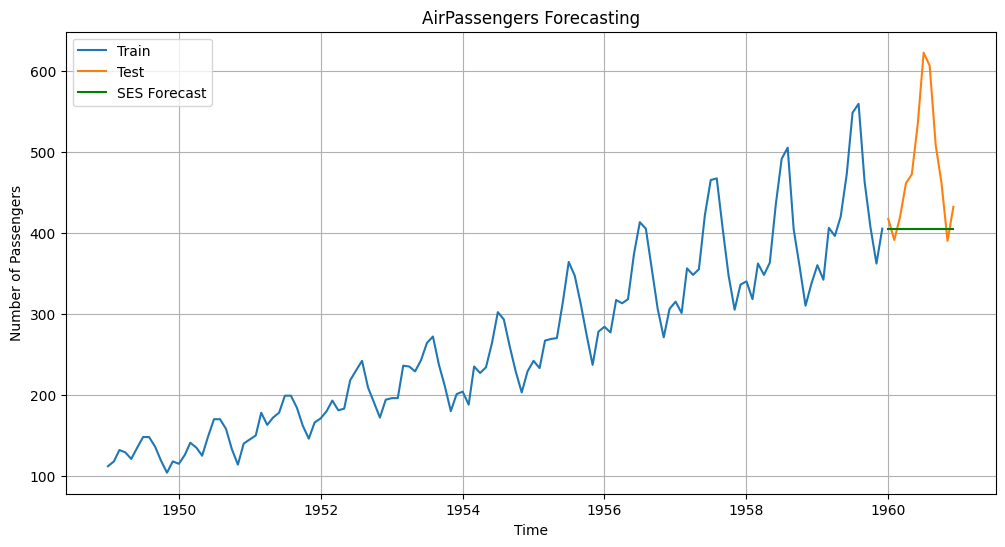

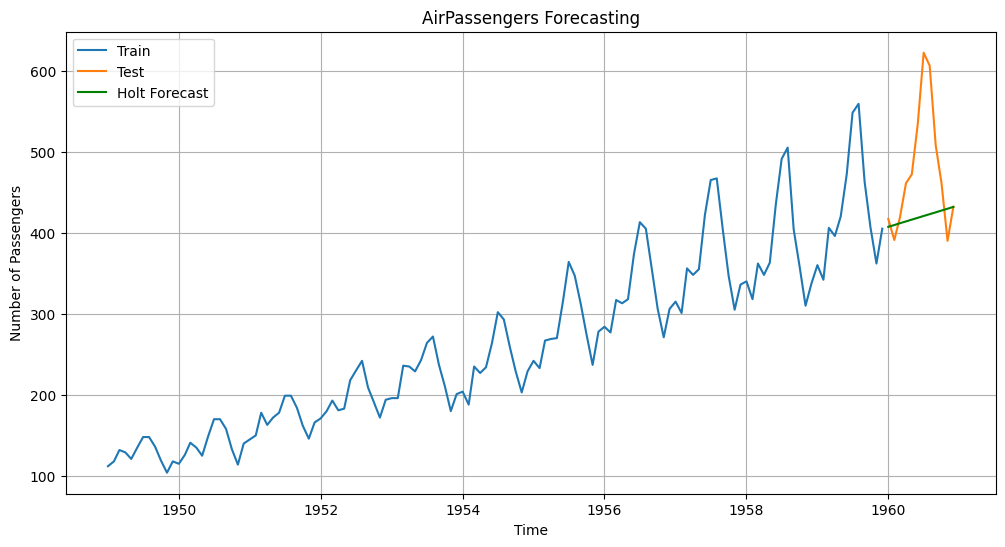

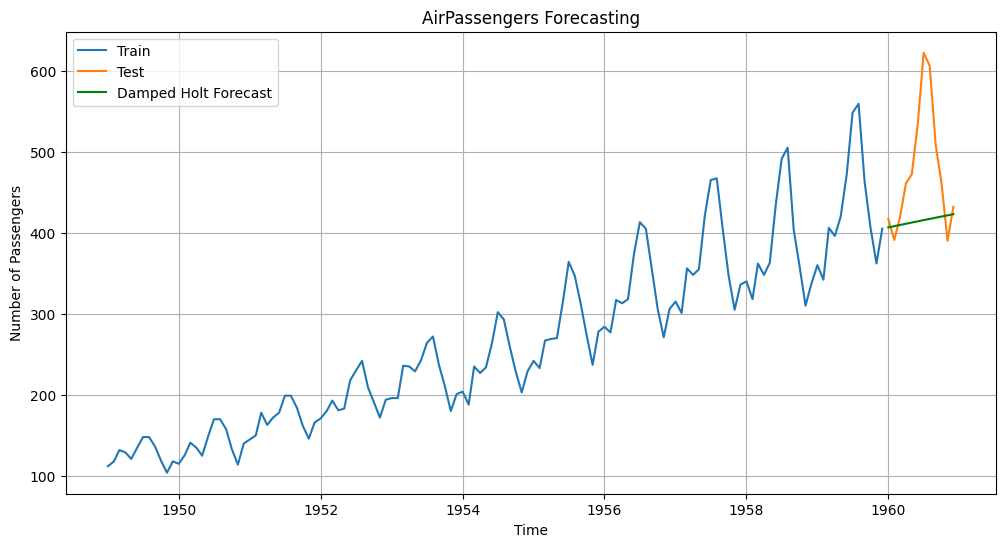

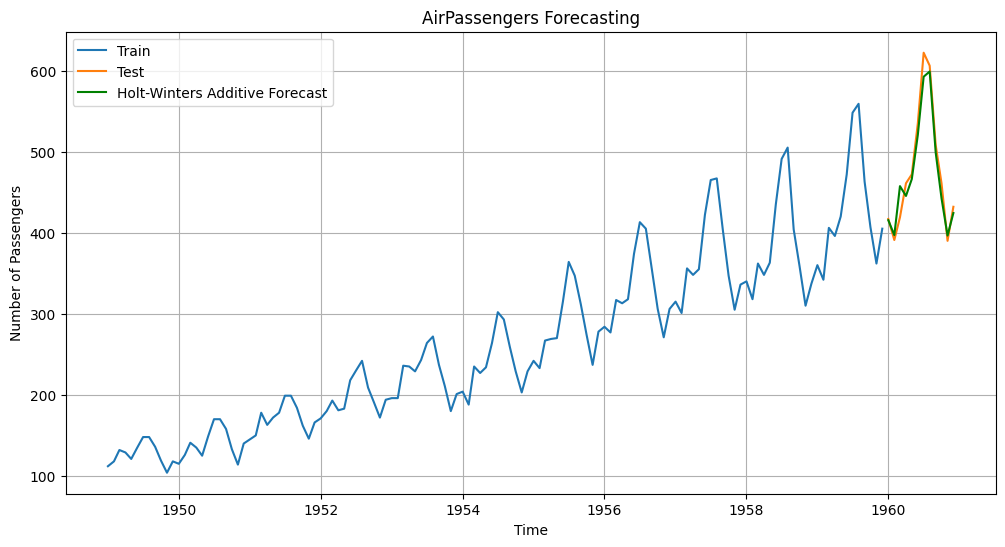

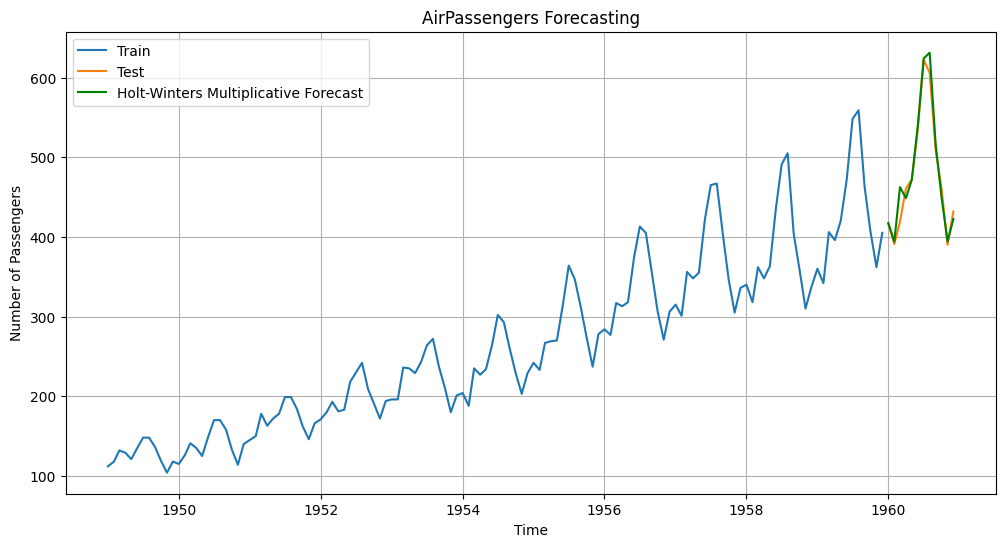

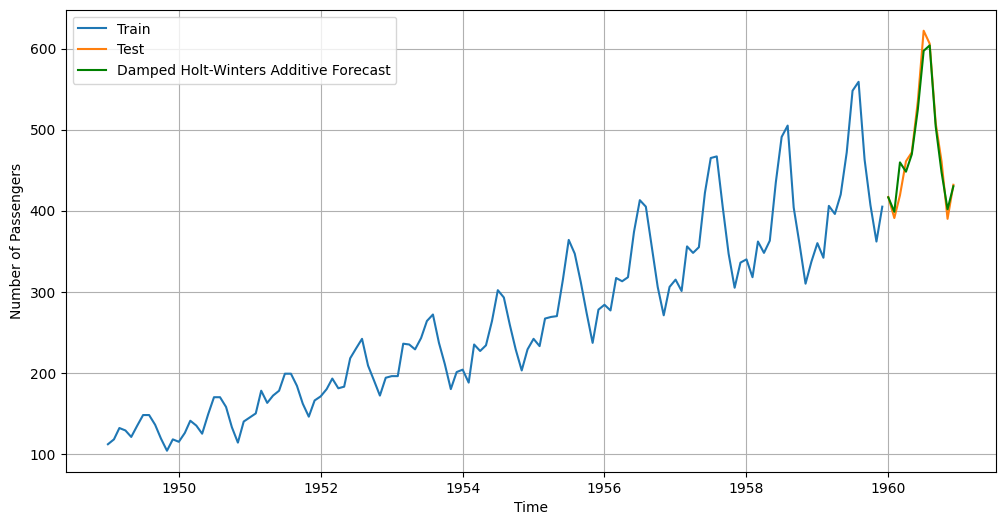

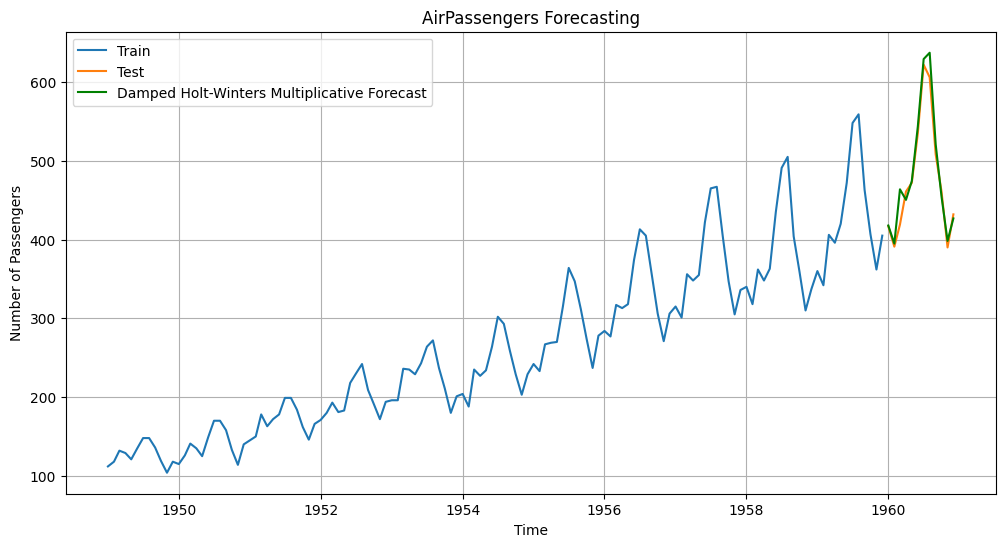

In [60]:
# Vẽ đồ thị dự báo
## 1. SES
plt.figure(figsize=(12,6))
plt.plot(train.index, train['Passengers'], label='Train')
plt.plot(test.index, test['Passengers'], label='Test')
plt.plot(test.index, ses_forecast, label='SES Forecast', color='green')
plt.title('AirPassengers Forecasting')
plt.xlabel('Time')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

## 2. Holt
plt.figure(figsize=(12,6))
plt.plot(train.index, train['Passengers'], label='Train')
plt.plot(test.index, test['Passengers'], label='Test')
plt.plot(test.index, holt_forecast, label='Holt Forecast', color='green')
plt.title('AirPassengers Forecasting')
plt.xlabel('Time')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

## 3. Damped Holt
plt.figure(figsize=(12,6))
plt.plot(train.index, train['Passengers'], label='Train')
plt.plot(test.index, test['Passengers'], label='Test')
plt.plot(test.index, holt_damped_forecast, label='Damped Holt Forecast', color='green')
plt.title('AirPassengers Forecasting')
plt.xlabel('Time')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()


## 4. Holt-Winters Additive
plt.figure(figsize=(12,6))
plt.plot(train.index, train['Passengers'], label='Train')
plt.plot(test.index, test['Passengers'], label='Test')
plt.plot(test.index, hw_forecast, label='Holt-Winters Additive Forecast', color='green')
plt.title('AirPassengers Forecasting')
plt.xlabel('Time')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

## 5. Holt-Winters Multiplicative
plt.figure(figsize=(12,6))
plt.plot(train.index, train['Passengers'], label='Train')
plt.plot(test.index, test['Passengers'], label='Test')
plt.plot(test.index, hw_mul_forecast, label='Holt-Winters Multiplicative Forecast', color='green')
plt.title('AirPassengers Forecasting')
plt.xlabel('Time')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

## 6. Damped Holt-Winters Additive
plt.figure(figsize=(12,6))
plt.plot(train.index, train['Passengers'], label='Train')
plt.plot(test.index, test['Passengers'], label='Test')
plt.plot(test.index, hw_damped_forecast, label='Damped Holt-Winters Additive Forecast', color='green')
plt.xlabel('Time')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

## 6. Damped Holt-Winters Multiplicative
plt.figure(figsize=(12,6))
plt.plot(train.index, train['Passengers'], label='Train')
plt.plot(test.index, test['Passengers'], label='Test')
plt.plot(test.index, hw_mul_damped_forecast, label='Damped Holt-Winters Multiplicative Forecast', color='green')
plt.title('AirPassengers Forecasting')
plt.xlabel('Time')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

**ĐÁNH GIÁ KẾT QUẢ DỰ BÁO TRÊN TẬP TEST**

In [61]:
# Đánh giá mô hình
## 1. MAE
from sklearn.metrics import mean_absolute_error
ses_mae = mean_absolute_error(test['Passengers'], ses_forecast)
holt_mae = mean_absolute_error(test['Passengers'], holt_forecast)
damped_holt_mae = mean_absolute_error(test['Passengers'], holt_damped_forecast)
hw_mae = mean_absolute_error(test['Passengers'], hw_forecast)
hw_mul_mae = mean_absolute_error(test['Passengers'], hw_mul_forecast)
hw_damped_mae = mean_absolute_error(test['Passengers'], hw_damped_forecast)
hw_mul_damped_mae = mean_absolute_error(test['Passengers'], hw_mul_damped_forecast)

## 2. MSE
from sklearn.metrics import mean_squared_error
ses_mse = mean_squared_error(test['Passengers'], ses_forecast)
holt_mse = mean_squared_error(test['Passengers'], holt_forecast)
damped_holt_mse = mean_squared_error(test['Passengers'], holt_damped_forecast)
hw_mse = mean_squared_error(test['Passengers'], hw_forecast)
hw_mul_mse = mean_squared_error(test['Passengers'], hw_mul_forecast)
hw_damped_mse = mean_squared_error(test['Passengers'], hw_damped_forecast)
hw_mul_damped_mse = mean_squared_error(test['Passengers'], hw_mul_damped_forecast)

## 3. RMSE
import numpy as np
ses_rmse = np.sqrt(ses_mse)
holt_rmse = np.sqrt(holt_mse)
damped_holt_rmse = np.sqrt(damped_holt_mse)
hw_rmse = np.sqrt(hw_mse)
hw_mul_rmse = np.sqrt(hw_mul_mse)
hw_damped_rmse = np.sqrt(hw_damped_mse)
hw_mul_damped_rmse = np.sqrt(hw_mul_damped_mse)

## 4. MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
ses_mape = mean_absolute_percentage_error(test['Passengers'], ses_forecast)
holt_mape = mean_absolute_percentage_error(test['Passengers'], holt_forecast)
damped_holt_mape = mean_absolute_percentage_error(test['Passengers'], holt_damped_forecast)
hw_mape = mean_absolute_percentage_error(test['Passengers'], hw_forecast)
hw_mul_mape = mean_absolute_percentage_error(test['Passengers'], hw_mul_forecast)
hw_damped_mape = mean_absolute_percentage_error(test['Passengers'], hw_damped_forecast)
hw_mul_damped_mape = mean_absolute_percentage_error(test['Passengers'], hw_mul_damped_forecast)


# In kết quả đánh giá
import pandas as pd

## 1. Tạo cấu trúc dữ liệu dạng Dictionary (Từ điển)
summary_data = {
    'Mô hình': [
        'SES',
        'Holt',
        'Damped Holt',
        'HW Additive',
        'HW Multiplicative',
        'Damped HW Additive',
        'Damped HW Multiplicative'
    ],
    'MAE': [ses_mae, holt_mae, damped_holt_mae, hw_mae, hw_mul_mae, hw_damped_mae, hw_mul_damped_mae],
    'MSE': [ses_mse, holt_mse, damped_holt_mse, hw_mse, hw_mul_mse, hw_damped_mse, hw_mul_damped_mse],
    'RMSE': [ses_rmse, holt_rmse, damped_holt_rmse, hw_rmse, hw_mul_rmse, hw_damped_rmse, hw_mul_damped_rmse],
    'MAPE (%)': [ses_mape, holt_mape, damped_holt_mape, hw_mape, hw_mul_mape, hw_damped_mape, hw_mul_damped_mape]
}

## 2. Chuyển thành DataFrame
df_evaluation = pd.DataFrame(summary_data)

## 3. Làm tròn kết quả đến 2 chữ số thập phân
df_evaluation = df_evaluation.round(2)

## 4. Hiển thị bảng
df_evaluation

,Mô hình,MAE,MSE,RMSE,MAPE (%)
0,SES,76.00,10604.17,102.98,14.25
1,Holt,66.31,8587.03,92.67,12.42
2,Damped Holt,69.48,9186.40,95.85,13.02
3,HW Additive,13.38,288.36,16.98,2.80
4,HW Multiplicative,10.30,249.97,15.81,2.21
5,Damped HW Additive,11.02,245.08,15.66,2.37
6,Damped HW Multiplicative,11.85,295.29,17.18,2.49


## **Bước 10:** Tiến hành dự báo bằng mô hình tốt nhất

**LỰA CHỌN MÔ HÌNH DỰ BÁO:**
Dựa trên kết quả đánh giá sai số trên tập Test, quyết định lựa chọn mô hình **Holt-Winters Multiplicative** để thực hiện dự báo cho các giai đoạn tiếp theo.

**HUẤN LUYỆN LẠI MÔ HÌNH TRÊN TOÀN BỘ DỮ LIỆU:**

In [62]:
# Huấn luyện lại mô hình trên toàn bộ dữ liệu
df = df.asfreq('MS')
final_model = ExponentialSmoothing(
    df['Passengers'],
    trend='add',
    seasonal='mul',
    seasonal_periods=12
).fit()

# Bộ tham số của mô hình sau khi huấn luyện lại
final_params = get_coefficients(final_model, has_trend=True, has_seasonal=True)
print("Bộ tham số của mô hình sau khi huấn luyện lại:")
print(f"α: {final_params[0]}, β: {final_params[1]}, γ: {final_params[2]}")

# Kiểm định Ljung-Box để kiểm tra xem chuỗi thời gian còn tính tự tương quan không
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = final_model.resid.dropna()
ljungbox_test = acorr_ljungbox(residuals, lags=[12, 24], return_df=True)
print("\nKết quả kiểm định Ljung-Box:")
print(ljungbox_test)

Bộ tham số của mô hình sau khi huấn luyện lại:
α: 0.319, β: 0.0, γ: 0.601

Kết quả kiểm định Ljung-Box:
      lb_stat  lb_pvalue
12  17.940623   0.117505
24  39.121518   0.026518


**THỰC HIỆN DỰ BÁO TƯƠNG LAI**

Thực hiện dự báo 12 tháng tiếp theo

In [63]:
forecast_future = final_model.forecast(12)

# Bảng giá trị dự báo cho 12 tháng tiếp theo
import pandas as pd
forecast_table = pd.DataFrame({
    'Thời gian': forecast_future.index,
    'Giá trị dự báo': forecast_future.round(3).values
})

forecast_table


,Thời gian,Giá trị dự báo
0,1961-01-01,445.242
1,1961-02-01,418.225
2,1961-03-01,465.310
3,1961-04-01,494.951
4,1961-05-01,505.476
5,1961-06-01,573.313
6,1961-07-01,663.596
7,1961-08-01,654.904
8,1961-09-01,546.761
9,1961-10-01,488.447


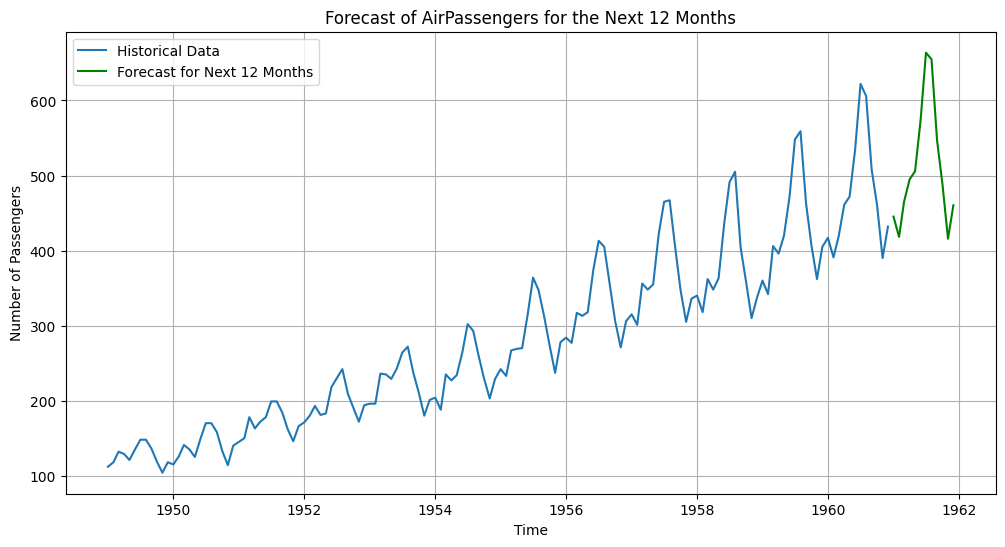

In [64]:
# vẽ đồ thị dự báo cho 12 tháng tiếp theo
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Passengers'], label='Historical Data')
plt.plot(forecast_future.index, forecast_future, label='Forecast for Next 12 Months', color='green')
plt.title('Forecast of AirPassengers for the Next 12 Months')
plt.xlabel('Time')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()